In [3]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset Files:", path)

c:\Users\flori\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os
import pandas
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from keras.utils import to_categorical
from keras.layers import Conv2D, Dense, Flatten, MaxPool2D, Dropout
from keras.models import Sequential

In [5]:
imgs_path = os.path.join(path, "Train")
data = []
labels = []
classes = 43

for i in range(classes):
    class_folder = os.path.join(imgs_path,str(i))
    for img in os.listdir(class_folder):
        im = Image.open(class_folder+"/"+img)
        im = im.resize((30,30))
        im = np.array(im)
        data.append(im)
        labels.append(i)
data = np.array(data)
labels = np.array(labels)

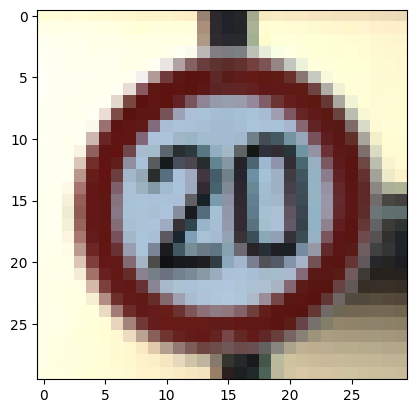

In [6]:
path = imgs_path + "/0/00000_00004_00029.png"
img = Image.open(path)
img = img.resize((30,30))
sr = np.array(img)
plt.imshow(img)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
print("Training Shape: ", x_train.shape, y_train.shape)
print("Testing Shape: ", x_test.shape, y_test.shape)

def to_categorical_M(y, num_classes):
    return np.eye(num_classes)[y]
y_train = to_categorical_M(y_train, 43)
y_test = to_categorical_M(y_test,43)

x_train = x_train / 255.0
x_test = x_test / 255.0

Training Shape:  (31367, 30, 30, 3) (31367,)
Testing Shape:  (7842, 30, 30, 3) (7842,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(filters=32,kernel_size=(5,5),activation="relu",input_shape=x_train.shape[1:]))
model.add(Conv2D(filters=32,kernel_size=(5,5),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu"))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(256,activation="relu"))
model.add(Dropout(rate=0.5))
model.add(Dense(43,activation="softmax"))
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

c:\Users\flori\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
epochs = 10

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=64,
    validation_data=(x_test,y_test)
)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.6256 - loss: 1.3538 - val_accuracy: 0.9547 - val_loss: 0.1705
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9351 - loss: 0.2241 - val_accuracy: 0.9824 - val_loss: 0.0686
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.9644 - loss: 0.1224 - val_accuracy: 0.9876 - val_loss: 0.0505
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.9761 - loss: 0.0831 - val_accuracy: 0.9850 - val_loss: 0.0539
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.9786 - loss: 0.0736 - val_accuracy: 0.9908 - val_loss: 0.0363
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.9823 - loss: 0.0594 - val_accuracy: 0.9903 - val_loss: 0.0347
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.9854 - loss: 0.0471 - val_accuracy: 0.9945 - val_loss: 0.0285
Epoch 8/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - accuracy: 0.9865 - loss: 0.0475 - 

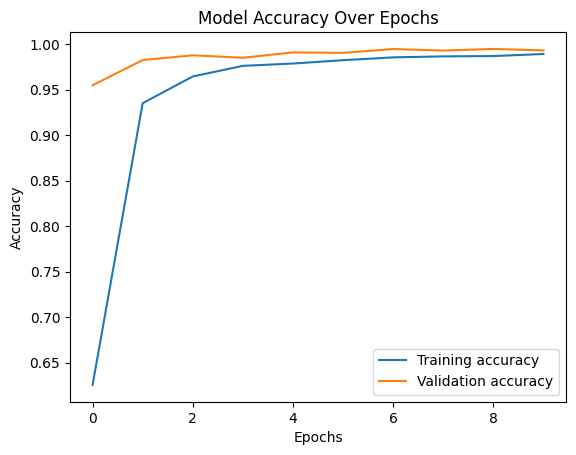

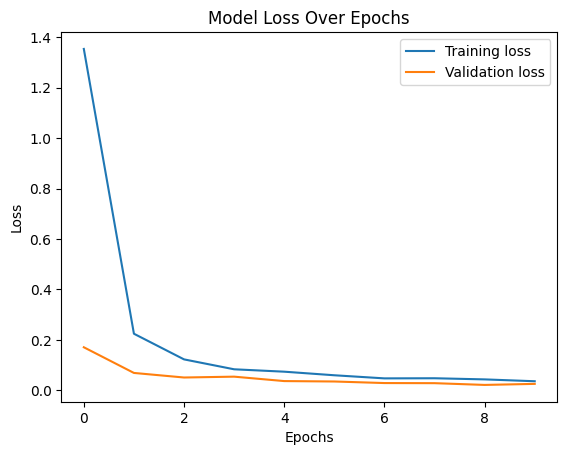

In [10]:
plt.figure(0)
plt.plot(history.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.figure(1)
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [24]:
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
from PIL import Image

test_path = r"C:\Users\flori\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1\Test.csv"
test = pd.read_csv(test_path)
test_labels = test["ClassId"].values
test_imgs = test["Path"].values

test_img_path = r"C:\Users\flori\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1"

In [25]:
test_data = []
for img in test_imgs:
    im = Image.open(test_img_path + "/" + img)
    im = im.resize((30,30))
    im = np.array(im)
    test_data.append(im)

test_data = np.array(test_data)

In [26]:
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

print("Accuracy:", accuracy_score(test_labels, predicted_classes))
model.save("traffic_classifier.h5")

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.9453681710213777
